# Pre-MS stars

This notebook can be used to have a quicklook at the that product for the simulations.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# PlatoSim libraries
import platosim.plot      as pt
import platosim.mocka     as mk
import platosim.utilities as ut
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:70% !important; }</style>"))

In [23]:
path = Path(os.getenv('PLATO_WORKDIR')) / 'pre-ms'
idir = path / 'input'
sdir = path / 'simulations' 

---
## 1. Stellar catalogue
---

In [16]:
# Load PLATO-CS catalogue
df = pd.read_feather(path / '../PlatoCS/input/starcat_PlatoCS_NCAM_LOPS2.ftr')

In [14]:
# Load Pre-MS catalogue
dt = pd.read_csv(path / 'input/plato_sample.txt', sep=' ', comment='#',
                 names=['ID', 'gaiaDR3', 'Pmag', 'Gmag', 'ra', 'dec'])
dt.head()

,ID,gaiaDR3,Pmag,Gmag,ra,dec
0,1,2885659097345755648,14.841428,15.018138,94.514026,-34.544374
1,2,2886290079581074432,15.142609,15.319207,93.342170,-35.022312
2,3,2890046080021476352,14.823780,14.999045,91.413240,-32.674862
3,4,2895540751943528960,16.155236,16.329124,97.784416,-29.021455
4,5,2895546146422412800,15.847063,16.032137,97.996331,-28.911655


<IPython.core.display.Javascript object>


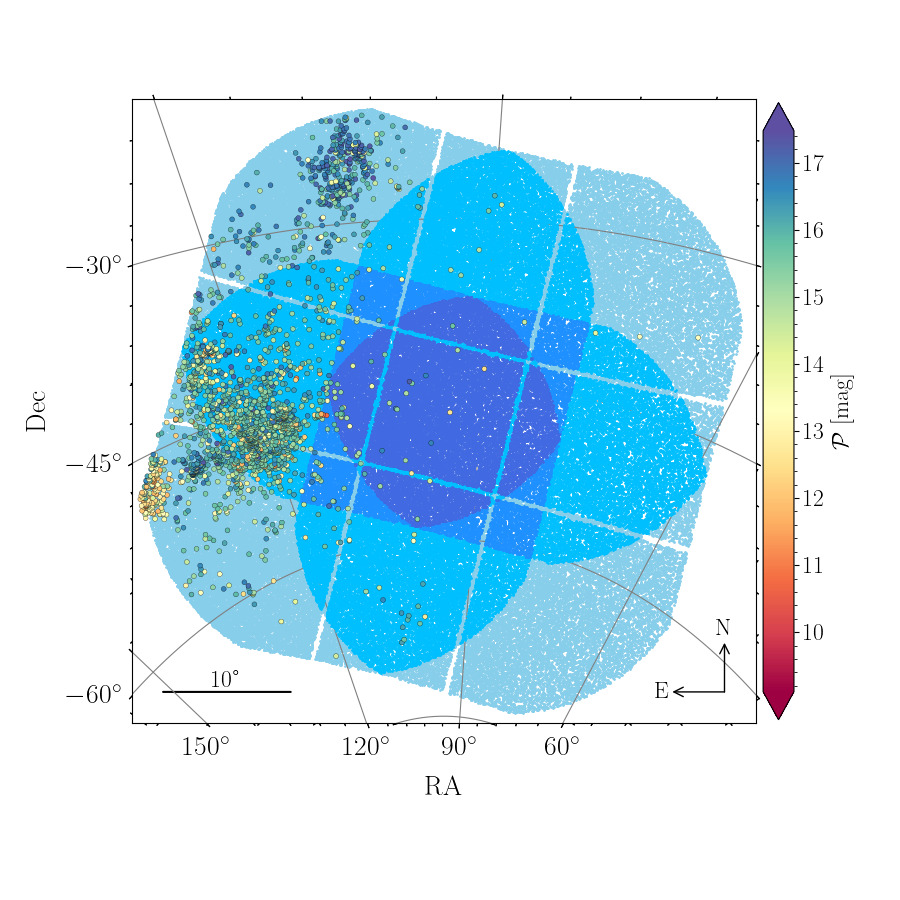

In [22]:
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=dt.ra, decStars=dt.dec, c=dt.Pmag, s=50, lw=0.2, 
                          ncamStars=True, clabel=r'$\mathcal{P}$ [mag]', figsize=(9,9))
# fig.savefig(f'{pdir}/starcat_sky_EBs.png', bbox_inches='tight', dpi=200)

In [19]:
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / 'starcat_PreMS_targets.ftr')

In [20]:
# Create contaminant catalogue
dc = ut.getContaminants(dt, df, column='gaiaDR3')
dc.to_feather(idir / 'starcat_PreMS_contaminants.ftr')

100%|██████████████████████████████████████████████████| 2452/2452 [04:30<00:00,


---
## 2. Post-processing
---

We ran a few test simulations saving the default photometry to the HDF5 file:
```
platonium 1 2 1 1 --project pre-ms --varsource_test.txt 
```

In [42]:
# Load file to test detrending with
filename = f"{sdir}/test/hdf5/000000001/000000001_Ncam2.1_Q1.hdf5"

# Load a single mission quarter light curve
lc = LightCurve(filename, mode="single")
dt = lc.star()
dt

,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,2.885659e+18,94.514026,-34.544374,14.841428,2,1,1,4,858.602157,2972.11676,7.70238,28.981898,16.754839,3,0.006829


<IPython.core.display.Javascript object>


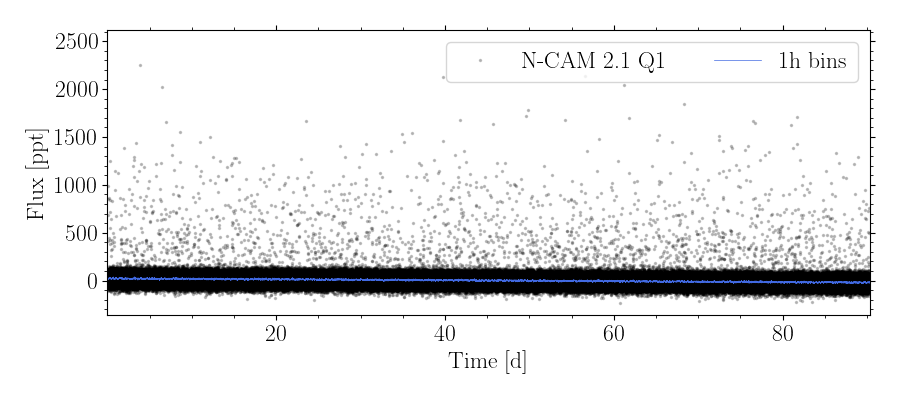

In [31]:
# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=False, figsize=(9,4));

### 2.1. Test detrending

<IPython.core.display.Javascript object>


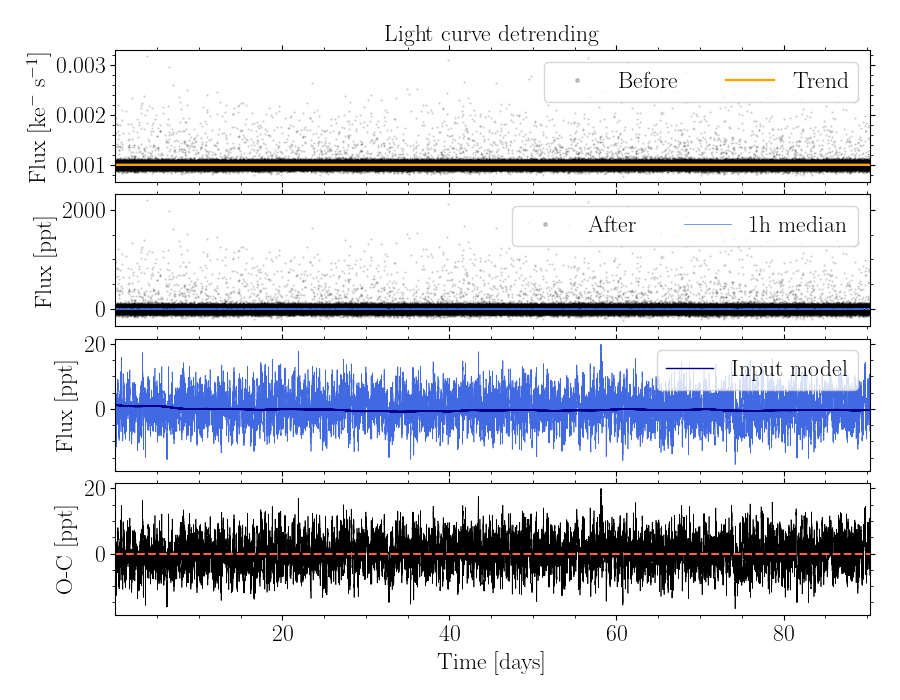

In [39]:
# Generate plot to save
df = lc.detrend(model='poly', replace=True, plot=True)

### 2.2. Test outlier rejection

<IPython.core.display.Javascript object>


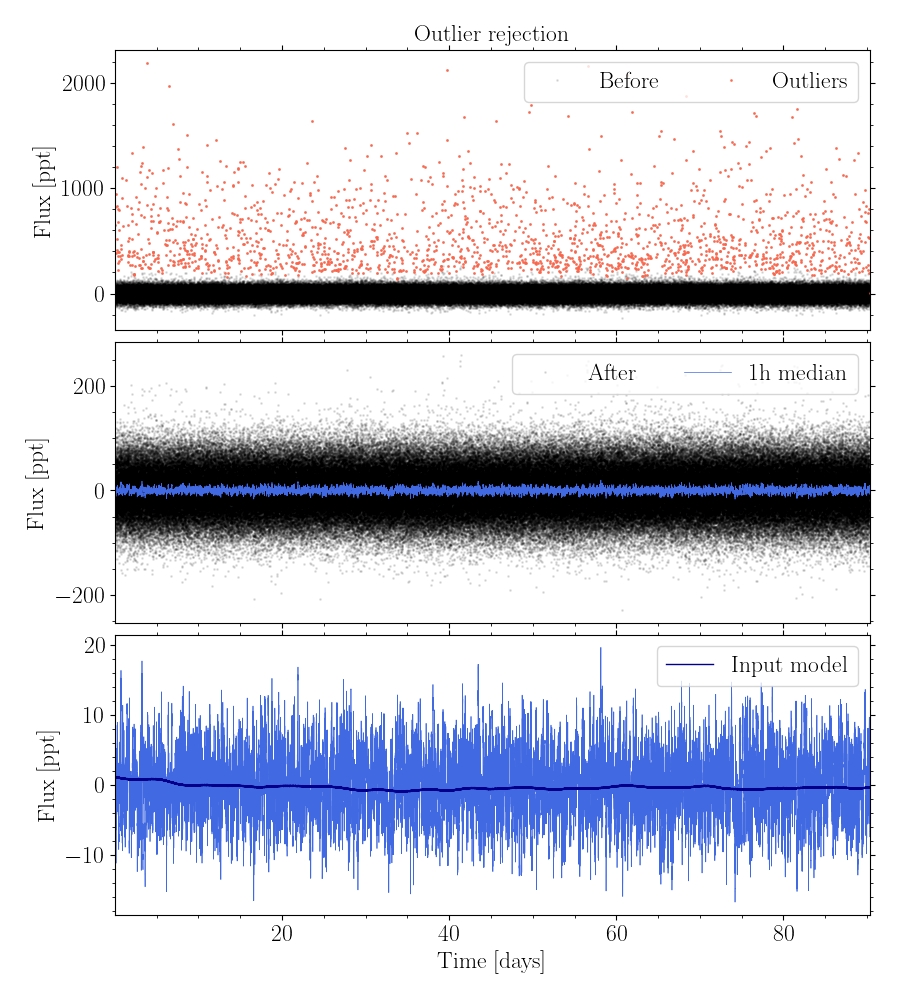

In [41]:
# Remove outliers (due to photon noise and cosmic ray hits)
df = lc.clip(model='wotan', sigma_lower=6, sigma_upper=3, flux_unit='ppt', plot=True)

---
## 3. Analysis of simulations
---

In [74]:
# path = '/lhome/nicholas/software/workdir/cs-binary/test_vsc/000000001'
star = '000000002'

# In multi mode we parse the entire directory of files
lcs = LightCurve(f'{path}/{star}', mode="multi")

In [83]:
lcs = LightCurve(f'{path}', mode="multi")

<bound method LightCurve.files of <platosim.lightcurve.LightCurve object at 0x7f4814251d90>>

In [63]:
lcs.unpack()

### *Use multi-mode as single-mode*

In [75]:
# Fetch files in folder
filenames = lcs.files(suffix='ftr')
filenames[:3]

['/lhome/nicholas/software/workdir/cs-exomoon/test_vsc/000000002/000000002_Ncam1.1_Q1.ftr',
 '/lhome/nicholas/software/workdir/cs-exomoon/test_vsc/000000002/000000002_Ncam1.1_Q2.ftr',
 '/lhome/nicholas/software/workdir/cs-exomoon/test_vsc/000000002/000000002_Ncam1.1_Q3.ftr']

In [76]:
# Again one can fetch the first light curve for this star
lc = LightCurve(filenames[0])
lc.data().head()

,time,flux
0,18.75,1.000658
1,43.75,0.999838
2,68.75,0.999355
3,93.75,1.000077
4,118.75,0.999925


### *Simulation statistics*

The `.table` files each contain a small overview of the specific simulation. It is much handier to have a single file to search information from, hence, we can merge to one single overview table as follows. It possible to remove the redundant `.table` files during the process using `clean=True`:

In [77]:
df = lcs.stat_sim_table(ofile=f'{path}/../table/lc_{star}.tab', clean=True)
df.head()

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.08


,ID,PIC,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,2,2763379000147,95.271476,-49.165609,8.5,1,1,1,4,1597.544244,3296.697700,8.712537,23.139441,30.055796,1,0.054770
1,2,2763379000147,95.271476,-49.165609,8.5,1,1,2,4,1829.704588,2903.057636,10.453630,30.224963,34.234683,1,0.052891
2,2,2763379000147,95.271476,-49.165609,8.5,1,1,3,4,1440.591138,2684.320149,10.009583,34.162237,27.230640,1,0.050120
3,2,2763379000147,95.271476,-49.165609,8.5,1,1,4,4,1212.277988,3078.666379,8.183523,27.064005,23.121004,1,0.053351
4,2,2763379000147,95.271476,-49.165609,8.5,1,1,5,4,1597.758034,3296.745504,8.713108,23.138581,30.059645,1,0.054894


### *View simulations*

In [78]:
fig, ax = lcs.plot_multi(suffix='ftr', group=1, camera=1, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

<IPython.core.display.Javascript object>

In [79]:
lc = lcs.merge(suffix='ftr', binsize=1/6, flux_group_mean=True, flux_offset=True, 
               ofile=f'{path}/../final/lc_{star}.ftr')

Merging light curves:


100%|██████████████████████████████████████████████████| 192/192 [00:33<00:00,  


Sorting data after timings
Averaging data from same camera group
Binning data per 0.16666666666666666h
Corrrecting flux offset of -15.49819897272986 ppm
Done!


In [80]:
lc.plot(input_model=True, flux_unit='ppm', median_filter=1, alpha=0.1, figsize=(9,6));

<IPython.core.display.Javascript object>

---
## Final data products
---

<IPython.core.display.Javascript object>


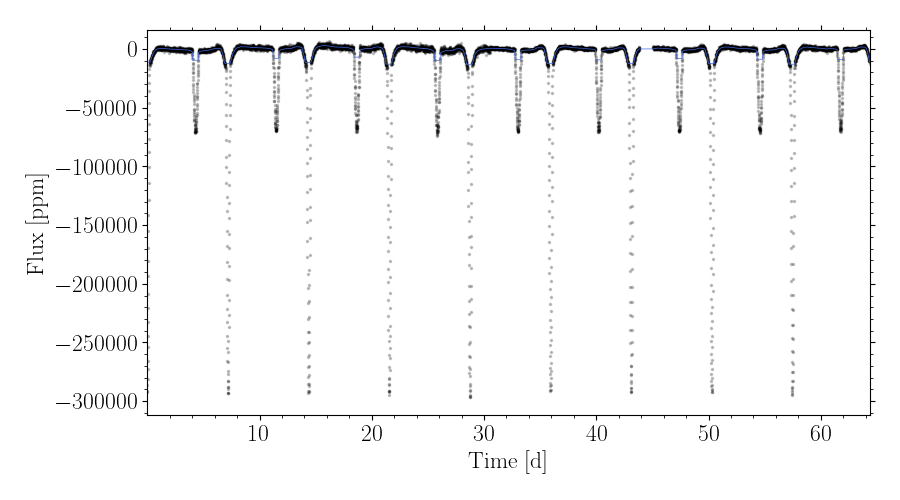

In [8]:
path = '/lhome/nicholas/software/workdir/cs-binary/finals'
star = 'mag085/lc_000000001.ftr'

# In multi mode we parse the entire directory of files
lc = LightCurve(f'{path}/{star}', mode="final")

# Introduce gaps from file
inputFileGap = '/lhome/nicholas/software/workdir/mocka/input/instrumentGAP.tab'
lc.gaps(inputFileGap, replace=True, plot=False);

# Show a quarter light curve
lc.plot(flux_unit='ppm', median_filter=1, input_model=True, legend=False, figsize=(9,5));

<IPython.core.display.Javascript object>


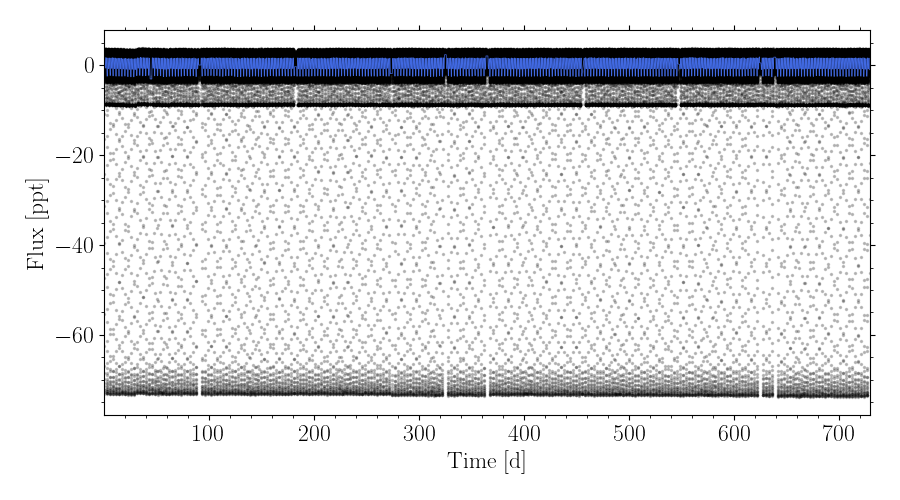

In [183]:
path = '/lhome/nicholas/software/workdir/cs-binary/finals'
star = 'mag085/lc_000000090.ftr'

# In multi mode we parse the entire directory of files
lc = LightCurve(f'{path}/{star}', mode="final")

# Introduce gaps from file
inputFileGap = '/lhome/nicholas/software/workdir/mocka/input/instrumentGAP.tab'
lc.gaps(inputFileGap, replace=True, plot=False);

# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=False, legend=False, figsize=(9,5));